<a href="https://colab.research.google.com/github/22495521/99-multiplication-table/blob/main/CNN_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

ZIP_SRC  = '/content/drive/MyDrive/colab_file/handwriting-data.zip'
ZIP_DST  = '/content/handwriting-data.zip'
DATA_DIR = '/content/data'


if not os.path.exists(ZIP_DST):
    !cp "{ZIP_SRC}" /content/
if not os.path.exists(DATA_DIR):
    !unzip -q "{ZIP_DST}" -d /content

In [57]:

import torch
import torchvision
from torchvision.transforms import v2
import gc
gc.collect()

8

In [58]:
IMG_SIZE = 28
train_dir = "/content/data/handwriting/augmented_images/augmented_images1"
test_dir  = "/content/data/handwriting/handwritten-english-characters-and-digits/combined_folder/test"
batch_size = 64

train_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomCrop(IMG_SIZE, padding=2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

test_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

trainset =  torchvision.datasets.ImageFolder(train_dir, transform=train_tf)
testset  =  torchvision.datasets.ImageFolder(test_dir,  transform=test_tf)

train_loader =  torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=10, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=10, pin_memory=True)


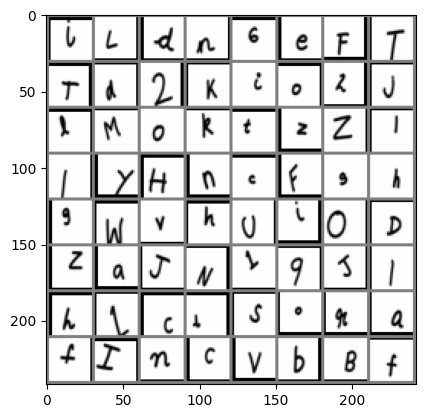

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [60]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 62)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [65]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

net = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

使用裝置: cuda


In [62]:

for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):

        inputs, labels = data[0].to(device), data[1].to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 50 == 49:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 50:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,    50] loss: 4.127
[1,   100] loss: 4.070
[1,   150] loss: 3.864
[1,   200] loss: 3.679
[2,    50] loss: 3.465
[2,   100] loss: 3.334
[2,   150] loss: 3.259
[2,   200] loss: 3.102
[3,    50] loss: 2.938
[3,   100] loss: 2.779
[3,   150] loss: 2.648
[3,   200] loss: 2.525
[4,    50] loss: 2.436
[4,   100] loss: 2.259
[4,   150] loss: 2.160
[4,   200] loss: 2.057
[5,    50] loss: 1.993
[5,   100] loss: 1.938
[5,   150] loss: 1.882
[5,   200] loss: 1.853
[6,    50] loss: 1.758
[6,   100] loss: 1.665
[6,   150] loss: 1.670
[6,   200] loss: 1.693
[7,    50] loss: 1.584
[7,   100] loss: 1.579
[7,   150] loss: 1.511
[7,   200] loss: 1.515
[8,    50] loss: 1.492
[8,   100] loss: 1.393
[8,   150] loss: 1.364
[8,   200] loss: 1.401
[9,    50] loss: 1.352
[9,   100] loss: 1.302
[9,   150] loss: 1.325
[9,   200] loss: 1.320
[10,    50] loss: 1.210
[10,   100] loss: 1.231
[10,   150] loss: 1.234
[10,   200] loss: 1.250
Finished Training


In [63]:

net.eval()

correct = 0
total = 0
test_loss = 0.0

print("開始評估...")

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

# 計算損失
average_test_loss = test_loss / len(testloader.dataset)
accuracy = 100. * correct / total

print(f'\n[Test Result] loss: {average_test_loss:.3f} | Accuracy: {accuracy:.2f}% ({correct}/{total})')
print('Finished Testing')

開始測試評估...

[Test Result] loss: 0.886 | Accuracy: 71.85% (490/682)
Finished Testing


In [64]:
# 統計每個類別的正確率
class_correct = list(0. for i in range(62))
class_total = list(0. for i in range(62))

net.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += c[i].item()
            class_total[label] += 1

# 類別名稱
classes = testset.classes

for i in range(len(classes)):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        print(f'類別 {classes[i]:<5s} 的正確率 : {acc:.1f}% ({int(class_correct[i])}/{int(class_total[i])})')
    else:
        print(f'類別 {classes[i]:<5s} 沒有測試樣本')

=== 各類別正確率分析 ===
類別 0     的正確率 : 9.1% (1/11)
類別 1     的正確率 : 72.7% (8/11)
類別 2     的正確率 : 81.8% (9/11)
類別 3     的正確率 : 81.8% (9/11)
類別 4     的正確率 : 81.8% (9/11)
類別 5     的正確率 : 63.6% (7/11)
類別 6     的正確率 : 63.6% (7/11)
類別 7     的正確率 : 81.8% (9/11)
類別 8     的正確率 : 45.5% (5/11)
類別 9     的正確率 : 90.9% (10/11)
類別 A_caps 的正確率 : 90.9% (10/11)
類別 B_caps 的正確率 : 54.5% (6/11)
類別 C_caps 的正確率 : 72.7% (8/11)
類別 D_caps 的正確率 : 100.0% (11/11)
類別 E_caps 的正確率 : 81.8% (9/11)
類別 F_caps 的正確率 : 90.9% (10/11)
類別 G_caps 的正確率 : 90.9% (10/11)
類別 H_caps 的正確率 : 100.0% (11/11)
類別 I_caps 的正確率 : 9.1% (1/11)
類別 J_caps 的正確率 : 90.9% (10/11)
類別 K_caps 的正確率 : 36.4% (4/11)
類別 L_caps 的正確率 : 81.8% (9/11)
類別 M_caps 的正確率 : 72.7% (8/11)
類別 N_caps 的正確率 : 81.8% (9/11)
類別 O_caps 的正確率 : 81.8% (9/11)
類別 P_caps 的正確率 : 90.9% (10/11)
類別 Q_caps 的正確率 : 90.9% (10/11)
類別 R_caps 的正確率 : 90.9% (10/11)
類別 S_caps 的正確率 : 90.9% (10/11)
類別 T_caps 的正確率 : 72.7% (8/11)
類別 U_caps 的正確率 : 90.9% (10/11)
類別 V_caps 的正確率 : 72.7% (8/11)
類別 W_caps 的正確率 : 81.8